## Clustering DAR dynamics 

Here, the responding DARs from the memory stage (DARs as found in h24_cocaine-saline, d14_cocaine-h24_cocaine and d14_cocaine-h24_cocaine) are clustered based on their dynamics in the (discrete) experimental time points. 

In [1]:
### loading python libraries
import os 
# standard libraries
import numpy as np
import pandas as pd

# single cell libraries
import scanpy as sc
sc.settings.verbosity = 0

# plotting libraries
from matplotlib import pyplot as plt

### for timeseries clustering
from tslearn.utils import to_time_series_dataset
from tslearn.clustering import TimeSeriesKMeans
from tslearn.datasets import CachedDatasets
from tslearn.preprocessing import TimeSeriesScalerMeanVariance, TimeSeriesResampler
from sklearn.cluster import KMeans

# other
import math #to round up
import warnings
warnings.filterwarnings('ignore') #ignore filter warnings

# own libraries
from plotting import *

In [61]:
os.getcwd()

'/fast/AG_Pombo/luna/2026_rebuttal/12_DARs-TRaCE'

In [62]:
### load single-cell dataset
adata_path = '/fast/AG_Pombo/luna/2026_rebuttal/12_DARs-TRaCE/260609.DNs.VTA.ATAC.seu.sub.data.late.781cells.h5ad'
adata = sc.read_h5ad(adata_path)

In [63]:
adata.var_names

Index(['chr1-3184958-3185226', 'chr1-3204016-3204258', 'chr1-3250836-3251399',
       'chr1-3264222-3264556', 'chr1-3360833-3361229', 'chr1-3420772-3421038',
       'chr1-3435627-3435913', 'chr1-3466489-3466780', 'chr1-3514939-3515152',
       'chr1-3536056-3536330',
       ...
       'chr2-163007144-163007343', 'chr3-17390093-17390418',
       'chr4-141090009-141090319', 'chr5-71749954-71750153',
       'chr8-92772618-92772842', 'chr9-43577502-43577720',
       'chr11-54498431-54498630', 'chr2-167589257-167589461',
       'chrX-130820026-130820225', 'chr18-84251274-84251473'],
      dtype='object', length=64049)

In [64]:
adata.var.columns

Index(['peakType', 'distToGeneStart', 'nearestGene', 'distToTSS', 'nearestTSS',
       'GC', 'N', 'count', 'percentile'],
      dtype='object')

In [66]:
# Check the current number of observations (cells) in your AnnData
print("Number of cells before removal:", adata.n_obs)

# Check the new number of cells after removal
print("Number of cells after removal:", adata.n_obs)

Number of cells before removal: 781
Number of cells after removal: 781


In [67]:
### merge control (saline) treatment into one timepoint
control_mask = adata.obs["treatment"] == 'saline'
adata.obs.loc[control_mask, 'timepoint'] = 'control'
adata.obs["timepoint"] = adata.obs["timepoint"].astype('category')

In [68]:
### set order of timepoints
#new_order = ['control','m30','h1','h4','h8','h24','d14']
new_order = ['control','h24','d14']
#new_order = ['control','h1','h4','h8','h24','d14']

adata.obs["timepoint"] = adata.obs["timepoint"].cat.reorder_categories(new_order)

In [69]:
### make replicate categorical
adata.obs["replicate"] = adata.obs["replicate"].astype('category')

In [70]:
# Load DARs and modified peaks. 
# Suggestion:
#DARs_path = "/fast/AG_Pombo/luna/2026_rebuttal/12_DARs-TRaCE/260609_vta.late.DARs.txt"
DARs_path = "/fast/AG_Pombo/luna/2026_rebuttal/11_DARs_TFenrichment-contrast/260610_vta.edgeR.onlyLATE_DARs.txt"

DARs_df = pd.read_csv(DARs_path, sep='\t')

DARs_df['peakID'] = DARs_df['peakID'].str.replace(":", "-")
modified_peakIDs = DARs_df['peakID'].to_numpy()

In [71]:
### calculate average expression in other timepoints
obs = adata[:,modified_peakIDs].X.toarray()
obs = pd.DataFrame(obs,columns=modified_peakIDs,index=adata.obs["timepoint"])
obs_average = obs.groupby(level=0).mean()

In [72]:
obs_average
obs_average2 = obs_average

In [73]:
index = ['control', 'h24', 'd14']
#index = ['control','h1','h4','h8','h24', 'd14']

# Calculate midpoints and add new rows
midpoints = ['control.h24', 'h24.d14']
#midpoints = ['control.h1', 'h1.h4', 'h4.h8','h8.h24', 'h24.d14']
for idx, midpoint in enumerate(midpoints):
    timepoints = midpoint.split('.')
    time1, time2 = timepoints[0], timepoints[1]
    
    # Calculate the midpoint values
    midpoint_values = obs_average2.loc[time1] + (obs_average2.loc[time2] - obs_average2.loc[time1]) / 2
    
    # Add new row to the dataframe
    obs_average2.loc[midpoint] = midpoint_values

# Specify the desired order of rows
desired_order = ['control', 'control.h24', 'h24', 'h24.d14', 'd14']
#desired_order = ['control', 'control.h1', 'h1', 'h1.h4', 'h4', 'h4.h8', 'h8', 'h8.h24', 'h24', 'h24.d14', 'd14']

# Reorder rows
obs_average2 = obs_average2.loc[desired_order]

# Display the new dataframe
print(obs_average2)

             chr1-5082767-5083566  chr1-15610059-15610876  \
timepoint                                                   
control                  0.222513                0.091623   
control.h24              0.231946                0.091789   
h24                      0.241379                0.091954   
h24.d14                  0.298467                0.128199   
d14                      0.355556                0.164444   

             chr1-20933346-20933786  chr1-23382522-23383627  \
timepoint                                                     
control                    0.062827                0.442408   
control.h24                0.103253                0.436721   
h24                        0.143678                0.431034   
h24.d14                    0.089617                0.524406   
d14                        0.035556                0.617778   

             chr1-34409514-34410166  chr1-37864401-37865596  \
timepoint                                                     
cont

In [74]:
### scale the average expression
obs_average2 = (obs_average2 - obs_average2.min())/(obs_average2.max() - obs_average2.min())

In [75]:
### create usuable format for time series
formatted_dataset = to_time_series_dataset(obs_average2.T.values.tolist())
formatted_dataset.shape #check that dataset is right size (3D)

(2718, 5, 1)

In [76]:
formatted_dataset_trans = obs_average2.transpose()
scaled_df = formatted_dataset_trans
scaled_df.shape

(2718, 5)

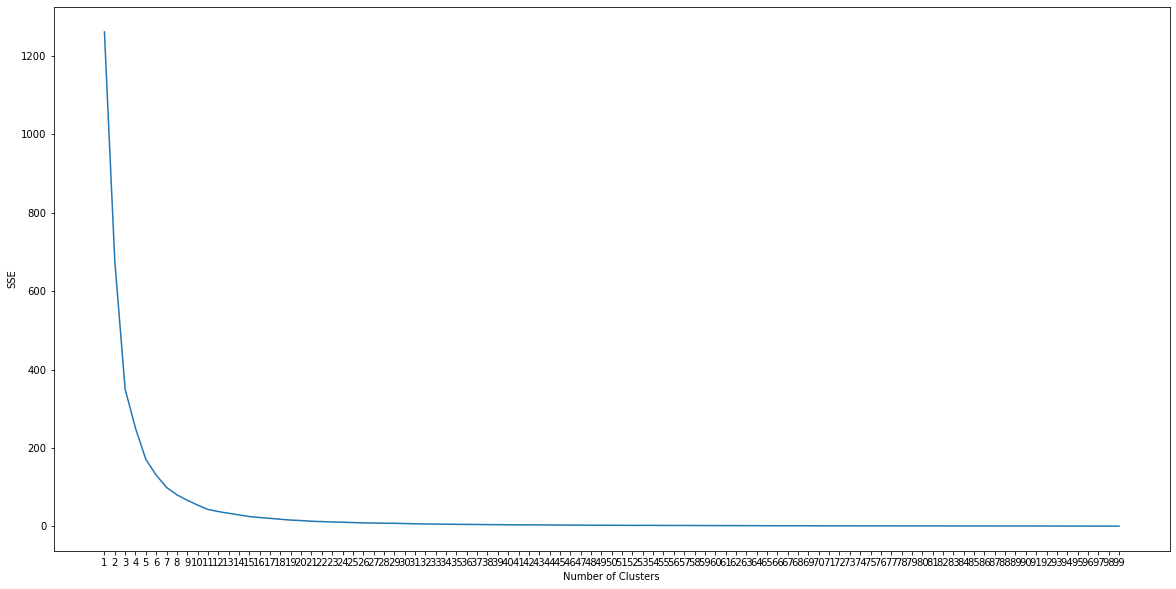

In [18]:
#Elbow:
#initialize kmeans parameters
kmeans_kwargs = {
"init": "random",
"n_init": 15,
"random_state": 1,
}

#create list to hold SSE values for each k
sse = []
for k in range(1, 100):
    kmeans = KMeans(n_clusters=k, **kmeans_kwargs)
    kmeans.fit(scaled_df)
    sse.append(kmeans.inertia_)
    
plt.figure(figsize=(20, 10))
#visualize results
plt.plot(range(1, 100), sse)
plt.xticks(range(1, 100))
plt.xlabel("Number of Clusters")
plt.ylabel("SSE")
plt.show()

In [77]:
### cluster DARs
seed = 0
np.random.seed(seed)

n_clust = 50 #preselect number of clusters

kmeans = TimeSeriesKMeans(n_clusters=n_clust, max_iter=15, random_state=seed)
y_pred = kmeans.fit_predict(formatted_dataset)

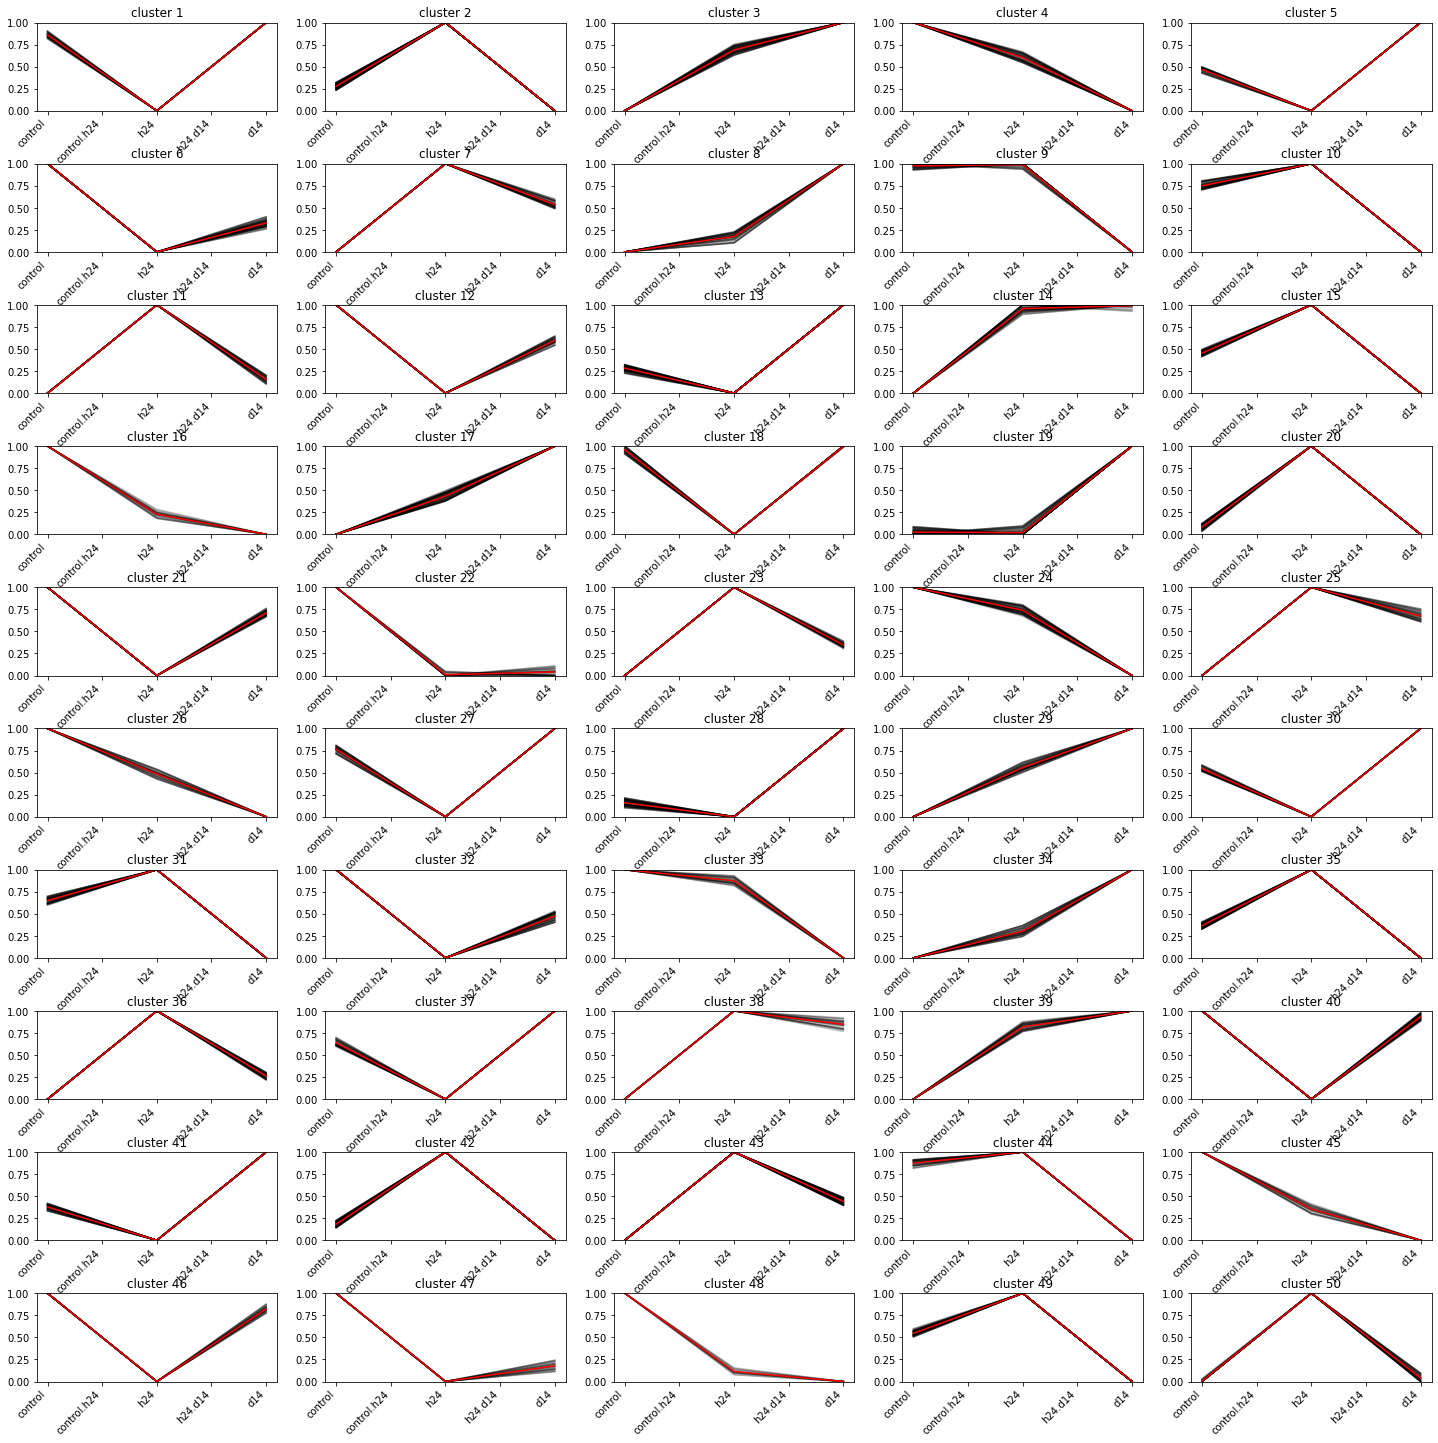

In [78]:
### plot clusters
fig, axs = plt.subplots(math.ceil(n_clust/5), 5,
                            figsize = (25,2.5*math.ceil(n_clust/5)),
                            gridspec_kw={'wspace':0.2, 'hspace':0.6})
axs = axs.ravel()
xticks = np.arange(len(desired_order))

for cluster in range(n_clust):

    for xx in formatted_dataset[y_pred == cluster]:
        axs[cluster].plot(xx.ravel(), "k-", alpha=.2)
    axs[cluster].plot(kmeans.cluster_centers_[cluster].ravel(), "r-")
    axs[cluster].set_ylim([0, 1])
    axs[cluster].set_xticks(xticks)
    axs[cluster].set_xticklabels(desired_order, rotation=45, ha='right')  
    #axs[cluster].set_xlim([0, 11])
    #axs[cluster].set_xticklabels(adata.obs["timepoint"].cat.categories)
    
    axs[cluster].title.set_text('cluster %d' % (cluster + 1))

### save figure
save_path = "/fast/AG_Pombo/luna/2026_rebuttal/12_DARs-TRaCE/260612_final_lateDARs_allsamples.png"
fig.savefig(save_path, bbox_inches='tight', format='png', dpi=300)
    
plt.show()

In [79]:
### make dictionary with names of genes in each cluster
dynamic_cluster_dict = {}

for cluster in range(n_clust):
    dynamic_cluster_dict[f"cluster{str(cluster+1)}"] = modified_peakIDs[y_pred == cluster]

In [80]:
### print genes in cluster of interest
dynamic_cluster_dict['cluster27']

array(['chr1-55171782-55172490', 'chr1-86038122-86038783',
       'chr1-135918626-135919186', 'chr1-153751851-153752267',
       'chr1-164461781-164462019', 'chr2-160367849-160368184',
       'chr3-126692894-126693628', 'chr4-106634212-106634447',
       'chr5-101854407-101854858', 'chr7-35246023-35246917',
       'chr7-126038369-126039106', 'chr8-121828935-121830058',
       'chr9-108824658-108825450', 'chr10-128737323-128737810',
       'chr11-74449648-74450148', 'chr11-89921002-89921607',
       'chr12-24498081-24499016', 'chr12-33388865-33389124',
       'chr12-50549648-50550118', 'chr12-69843566-69844293',
       'chr14-17172335-17173073', 'chr14-30981919-30982419',
       'chr15-76682869-76683365', 'chr15-76952402-76952702',
       'chr15-103163010-103163606', 'chr17-72858048-72858557',
       'chr19-10304416-10305175', 'chrX-95956506-95957243',
       'chr1-75457960-75458825', 'chr1-179231886-179232722',
       'chr2-13858573-13859325', 'chr2-30205260-30206407',
       'chr2-659

In [81]:
#Code by Luna:
#I want to convert the dictionary to a dataframe and save it. 
dynamic_cluster_df = pd.DataFrame.from_dict(dynamic_cluster_dict, 'index').stack().reset_index(level=0)
dynamic_cluster_df[0] = dynamic_cluster_df[0].str.replace('-', ':', 1)

#Save it:
dynamic_cluster_df.to_csv('260612_DARs_memory_kmeans_version2_smooth.csv', index=False)  # Set index=False to exclude the index column

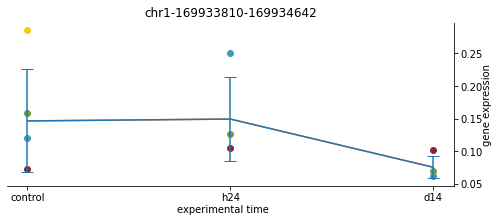

In [46]:
plot_gene_in_time(adata, 'chr1-169933810-169934642')